   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

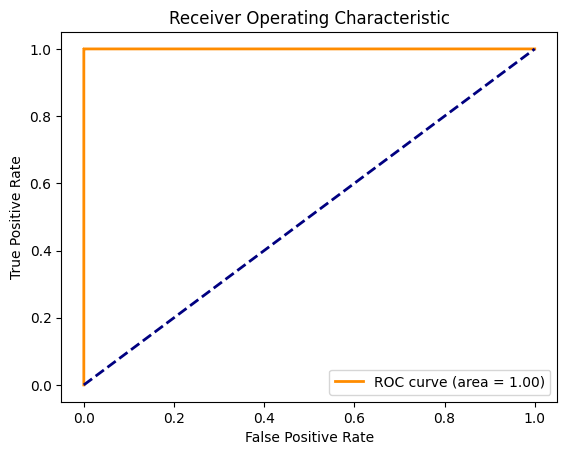

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Cargar los datos desde el archivo CSV
data = pd.read_csv("C:/Users/David_DZC/Desktop/Ciencia de Datos (Anahuac)/Proyecto Final/creditcard.csv")

# Explorar el conjunto de datos para verificar su contenido
print(data.head())  # Mostrar las primeras filas del dataset
print(data.info())  # Resumen de columnas y tipos de datos

# Separar las características (X) y la etiqueta (y)
X = data.drop("Class", axis=1)  # Eliminar la columna 'Class' del conjunto de características
y = data["Class"]  # La columna 'Class' es la etiqueta objetivo

# Aplicar SMOTE para balancear las clases (sobre-muestreo de la clase minoritaria)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Crear el modelo de Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

# Realizar predicciones en los datos de prueba
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probabilidades de la clase positiva

# Evaluar el modelo
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))  # Matriz de confusión para observar aciertos y errores

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))  # Métricas de precisión, recall, y f1-score

roc_auc = roc_auc_score(y_test, y_pred_proba)  # Calcular el AUC-ROC
print(f"\nAUC-ROC: {roc_auc}")

# Graficar la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Fin del código
